# **Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score
)

# **Dataset**

In [ ]:
try:
  df = pd.read_csv("Churn_Dataset.csv")

except FileNotFoundError:
  splits = {'train': 'train.csv', 'validation': 'validation.csv', 'test': 'test.csv'}
  df = pd.read_csv("hf://datasets/aai510-group1/telco-customer-churn/" + splits["train"])
  df.to_csv("Churn_Dataset.csv", index=False)

In [ ]:
print(df)

      Age  Avg Monthly GB Download  Avg Monthly Long Distance Charges  \
0      72                        4                              19.44   
1      27                       59                              45.62   
2      59                        0                              16.07   
3      25                       27                               0.00   
4      31                       21                              17.22   
...   ...                      ...                                ...   
4220   36                        0                               7.76   
4221   77                       22                              23.43   
4222   56                        0                              28.06   
4223   45                       22                               0.00   
4224   45                       22                              12.69   

       Churn Category         Churn Reason  Churn Score              City  \
0                 NaN                  NaN    

In [ ]:
print("="*10, "Dataset Information", "="*10)
print("Dataset Columns:", df.shape[1])
print("Dataset Rows:", df.shape[0])

========== Dataset Information ==========
Dataset Columns: 52
Dataset Rows: 4225


## **Data Cleaning**

In [ ]:
nan_cols = df.isna().sum()
nan_cols[nan_cols > 0]

,0
Churn Category,3104
Churn Reason,3104
Internet Type,886
Offer,2324


In [1]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of DataFrame')
plt.show()

NameError: name 'plt' is not defined

In [ ]:
df.drop(["Churn Category",
         "Churn Reason",
         "Customer Status",
         "Customer ID", #we drop this because they are irrelevant for the model
         "Zip Code",
         "Churn Score",
         "City",
         "Lat Long",
         "Latitude",
         "Longitude",
         "Satisfaction Score"],
        inplace=True,
        axis=1)
df.fillna({"Internet Type":"No Type Given"}, inplace=True)
df.fillna({"Offer":"No Offer Given"}, inplace=True)


In [ ]:
print("="*10, "Cleaned Dataset Information", "="*10)
print(f"Columns: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")

========== Cleaned Dataset Information ==========
Columns: 41
Rows: 4225


## **Imbalance**

In [ ]:
threshold = 0.7

biased_cols = []

for col in df.columns:
  vc = df[col].value_counts(normalize=True)

  max_ratio = vc.max()

  if max_ratio > threshold:
    biased_cols.append(col)
    print(f"\n>>> Imbalanced Feature: {col}")
    print(vc)
    if max_ratio > 0.90:
      df.drop(col, inplace=True, axis=1)
      print(f"Imbalanced Feature, Dropped {col}!")
      biased_cols.remove(col)


>>> Imbalanced Feature: Country
Country
United States    1.0
Name: proportion, dtype: float64
Imbalanced Feature, Dropped Country!

>>> Imbalanced Feature: Dependents
Dependents
0    0.766864
1    0.233136
Name: proportion, dtype: float64

>>> Imbalanced Feature: Internet Service
Internet Service
1    0.790296
0    0.209704
Name: proportion, dtype: float64

>>> Imbalanced Feature: Number of Dependents
Number of Dependents
0    0.766864
1    0.079763
3    0.074793
2    0.074556
5    0.001893
4    0.001657
6    0.000237
8    0.000237
Name: proportion, dtype: float64

>>> Imbalanced Feature: Online Security
Online Security
0    0.707456
1    0.292544
Name: proportion, dtype: float64

>>> Imbalanced Feature: Phone Service
Phone Service
1    0.899408
0    0.100592
Name: proportion, dtype: float64

>>> Imbalanced Feature: Premium Tech Support
Premium Tech Support
0    0.703432
1    0.296568
Name: proportion, dtype: float64

>>> Imbalanced Feature: Quarter
Quarter
Q3    1.0
Name: proportion,

In [ ]:
print("="*10, "Biased Features", "="*10)
for i in biased_cols:
  print(i)

========== Biased Features ==========
Dependents
Internet Service
Number of Dependents
Online Security
Phone Service
Premium Tech Support
Senior Citizen
Total Extra Data Charges
Under 30
Churn


# **Models**

## **Feature Engineering**

In [ ]:
txt_cols = []

print("="*10, "Text Features", "="*10)
for col in df.columns:
  if df[col].dtype == "object":
    txt_cols.append(col)
    print(col)

========== Text Features ==========
Contract
Gender
Internet Type
Offer
Payment Method


In [ ]:
num_cols = []

print("="*10, "Numerical Features", "="*10)
for col in df.columns:
  if len(df[col].unique()) > 2 and df[col].dtype != "object":
    num_cols.append(col)
    print(col)

========== Numerical Features ==========
Age
Avg Monthly GB Download
Avg Monthly Long Distance Charges
CLTV
Monthly Charge
Number of Dependents
Number of Referrals
Population
Tenure in Months
Total Charges
Total Extra Data Charges
Total Long Distance Charges
Total Revenue


In [ ]:
binary_cols = []

print("="*10, "Binary Features", "="*10)
for col in df.columns:
  if len(df[col].unique()) == 2 and df[col].dtype != "object":
    binary_cols.append(col)
    print(col)

========== Binary Features ==========
Dependents
Device Protection Plan
Internet Service
Married
Multiple Lines
Online Backup
Online Security
Paperless Billing
Partner
Phone Service
Premium Tech Support
Referred a Friend
Senior Citizen
Streaming Movies
Streaming Music
Streaming TV
Under 30
Unlimited Data
Churn


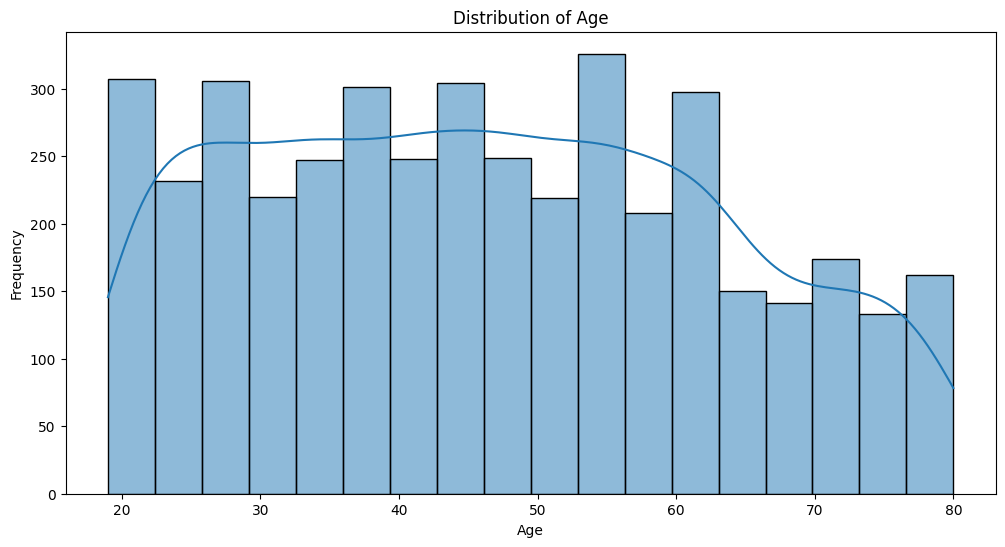

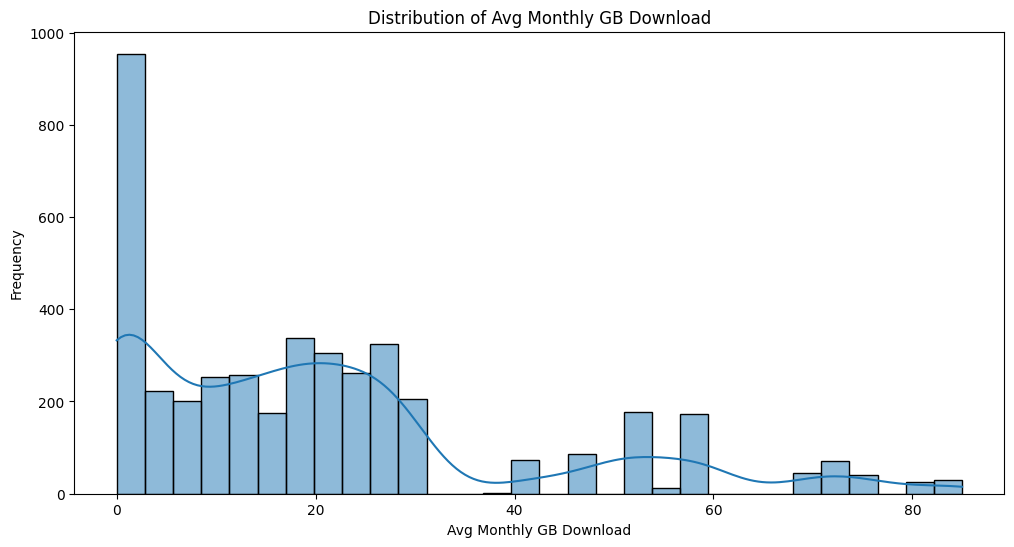

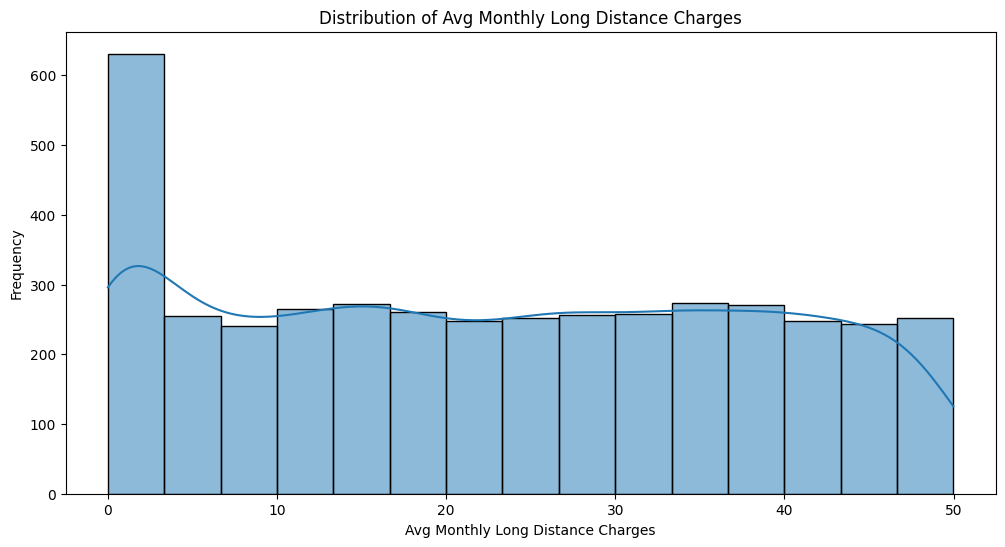

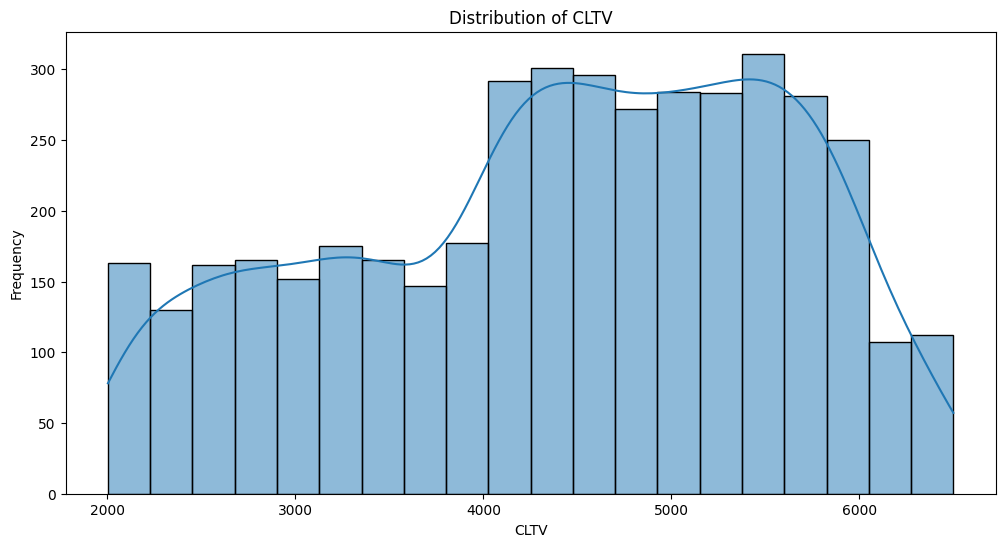

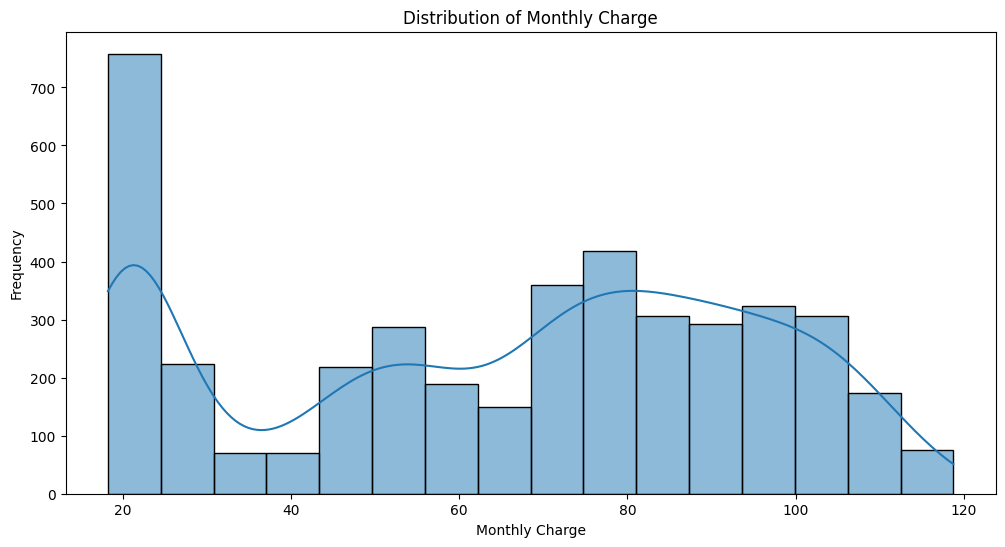

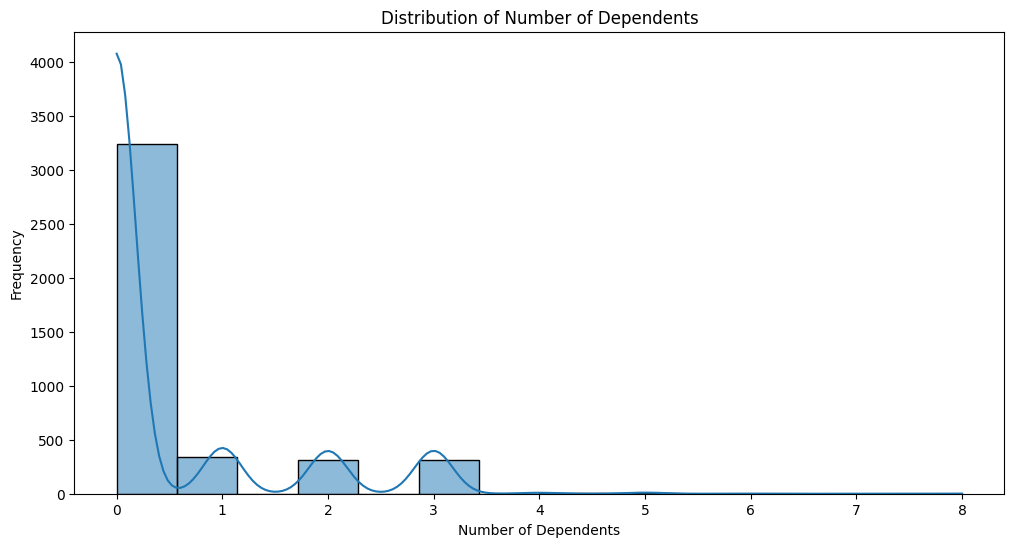

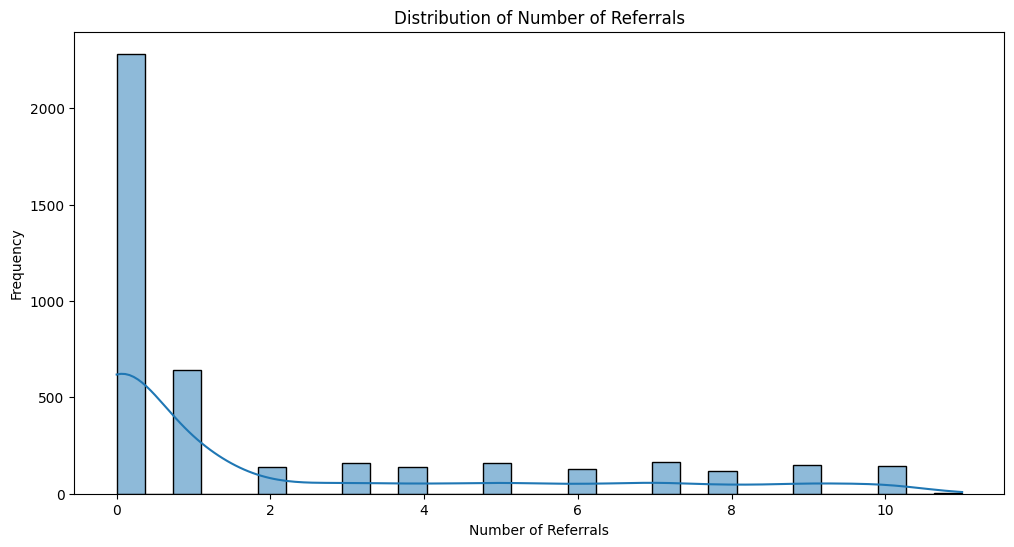

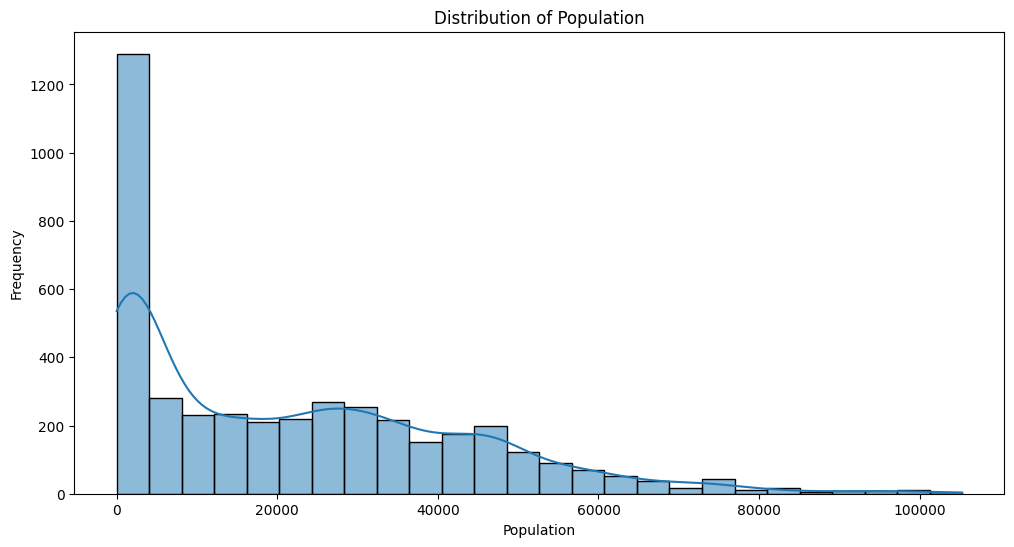

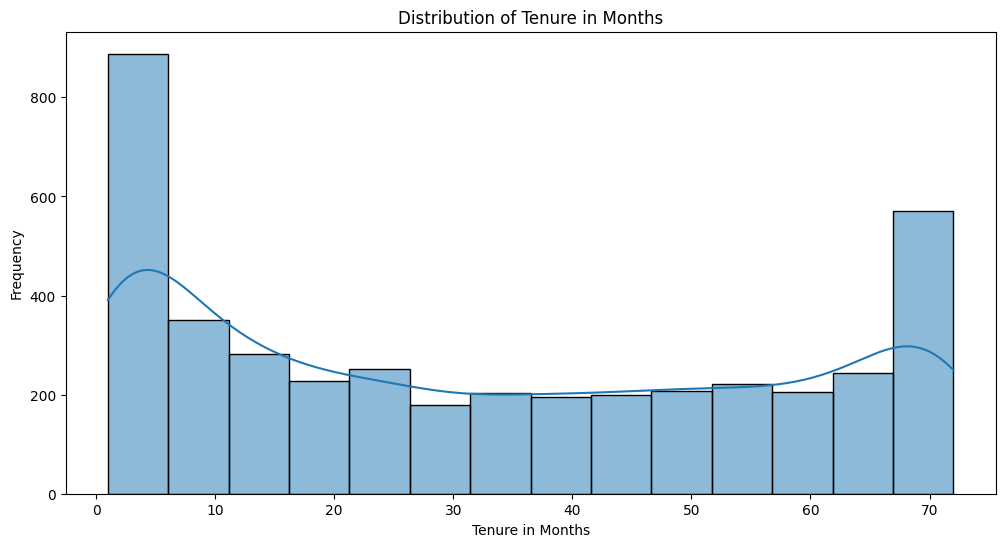

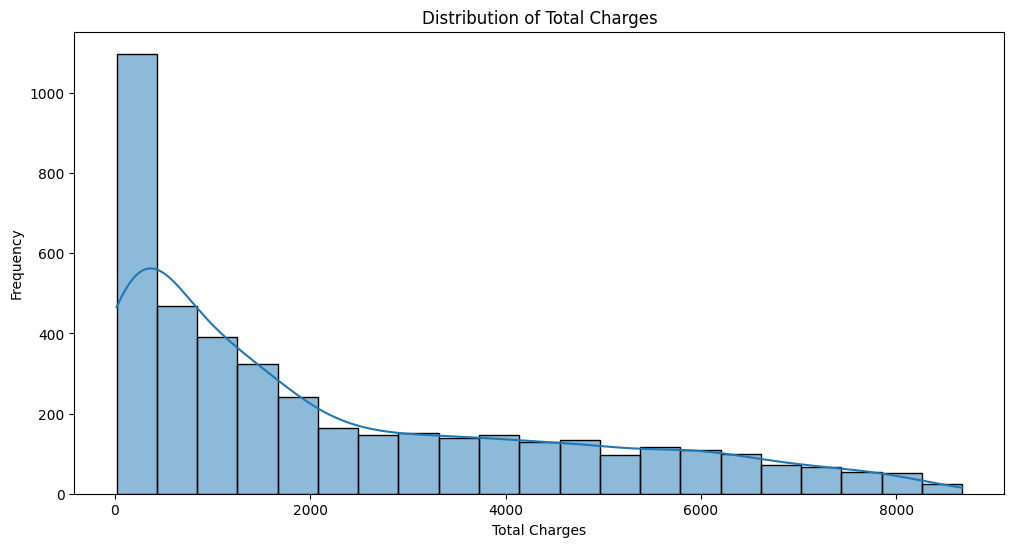

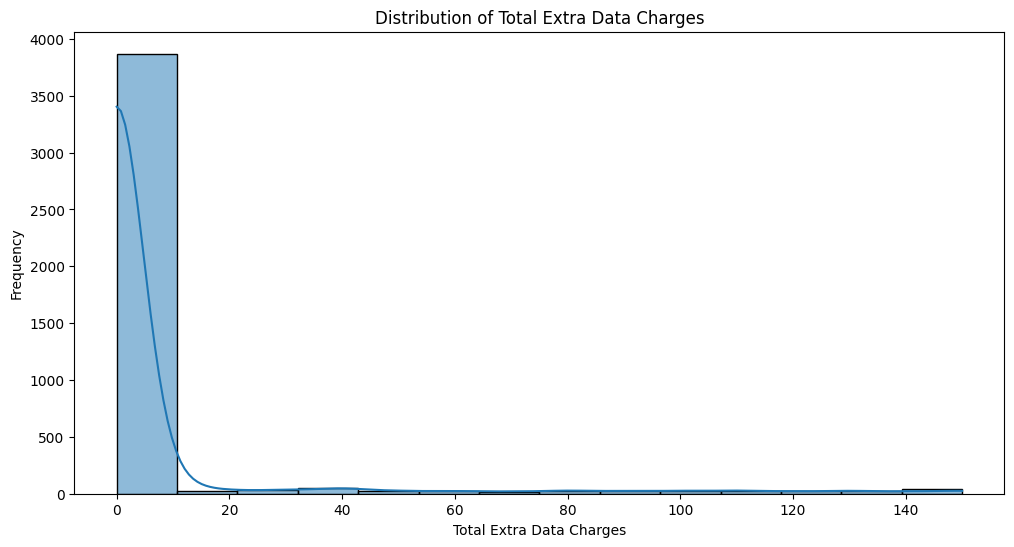

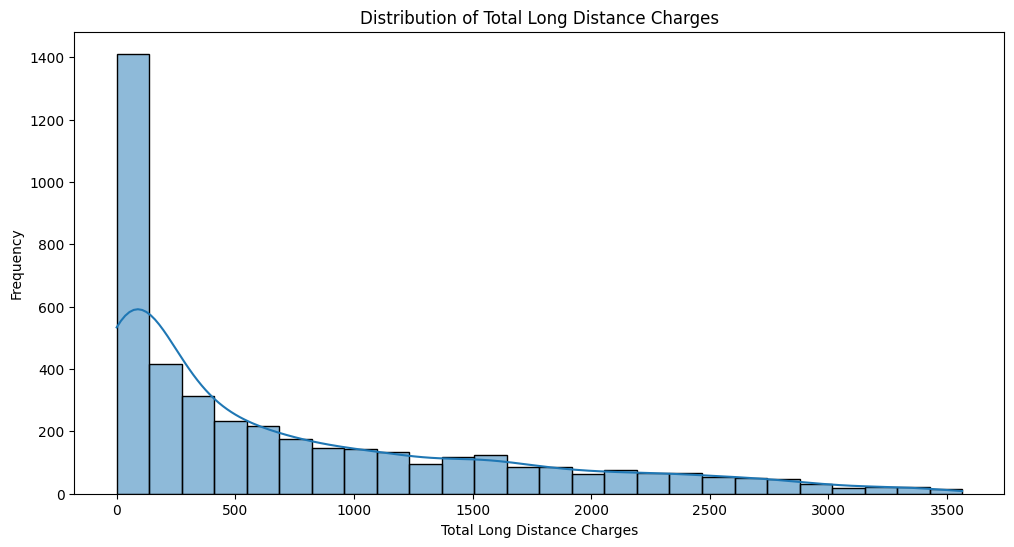

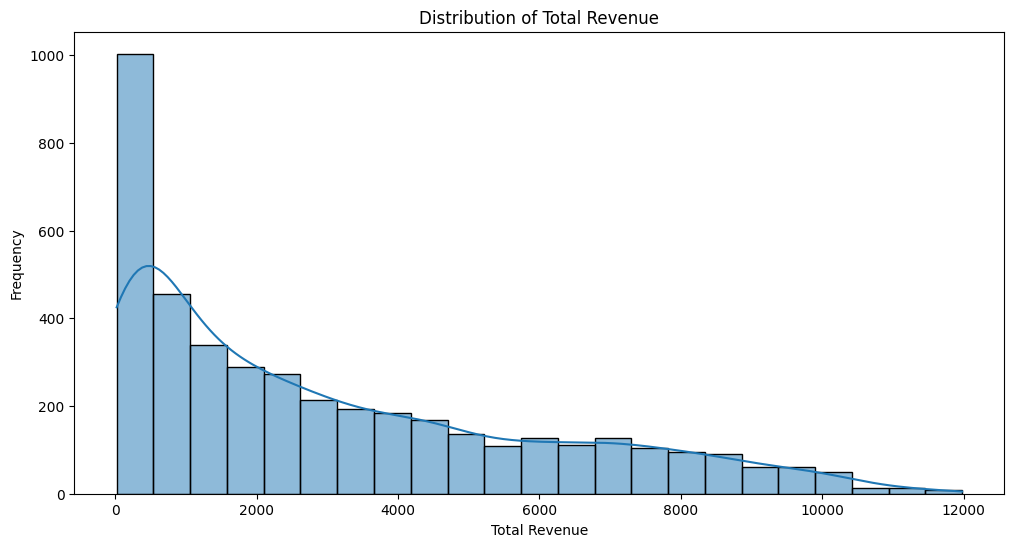

In [ ]:
for col in num_cols:
  plt.figure(figsize=(12,6))
  sns.histplot(data=df, x=col, kde=True)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# For decision tree only
preprocess_tree = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), txt_cols),
        ('num', 'passthrough', num_cols)
    ]
)
# normalized for NB and MLP
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), txt_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

XDT_trainproc = preprocess_tree.fit_transform(X_train)
XDT_testproc = preprocess_tree.transform(X_test)

X_trainproc = preprocess.fit_transform(X_train)
X_testproc = preprocess.transform(X_test)

## **Decision Tree**

In [ ]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(XDT_trainproc, y_train)

print("="*10, "SHAPE INFO", "="*10)
print("X_train:", X_train.shape)
print("X_train SMOTE :", X_train_sm.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_train SMOTE:", y_train_sm.shape)
print("y_test :", y_test.shape)

print("\n")
print("="*10, "TARGET DISTRIBUTION", "="*10)
print("Original Train:\n", y_train.value_counts(normalize=True))
print("\nOriginal Test:\n", y_test.value_counts(normalize=True))

print("\n")
print("="*10, "TARGET DISTRIBUTION (After SMOTE)", "="*10)
print("SMOTE Train:\n", y_train_sm.value_counts(normalize=True))

========== SHAPE INFO ==========
X_train: (3380, 36)
X_train SMOTE : (4966, 31)
X_test : (845, 36)
y_train: (3380,)
y_train SMOTE: (4966,)
y_test : (845,)


========== TARGET DISTRIBUTION ==========
Original Train:
 Churn
0    0.734615
1    0.265385
Name: proportion, dtype: float64

Original Test:
 Churn
0    0.734911
1    0.265089
Name: proportion, dtype: float64


========== TARGET DISTRIBUTION (After SMOTE) ==========
SMOTE Train:
 Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_sm, y_train_sm)

y_pred = dt.predict(XDT_testproc)

print("="*10, "Balanced Accuracy (SMOTE)", "="*10, "\n", balanced_accuracy_score(y_test, y_pred))

dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(XDT_trainproc, y_train)

y_pred2 = dt2.predict(XDT_testproc)

print("="*10, "Balanced Accuracy", "="*10, "\n", balanced_accuracy_score(y_test, y_pred2))


========== Balanced Accuracy (SMOTE) ========== 
 0.7603807223372441
========== Balanced Accuracy ========== 
 0.7211906199677939


### Visualization

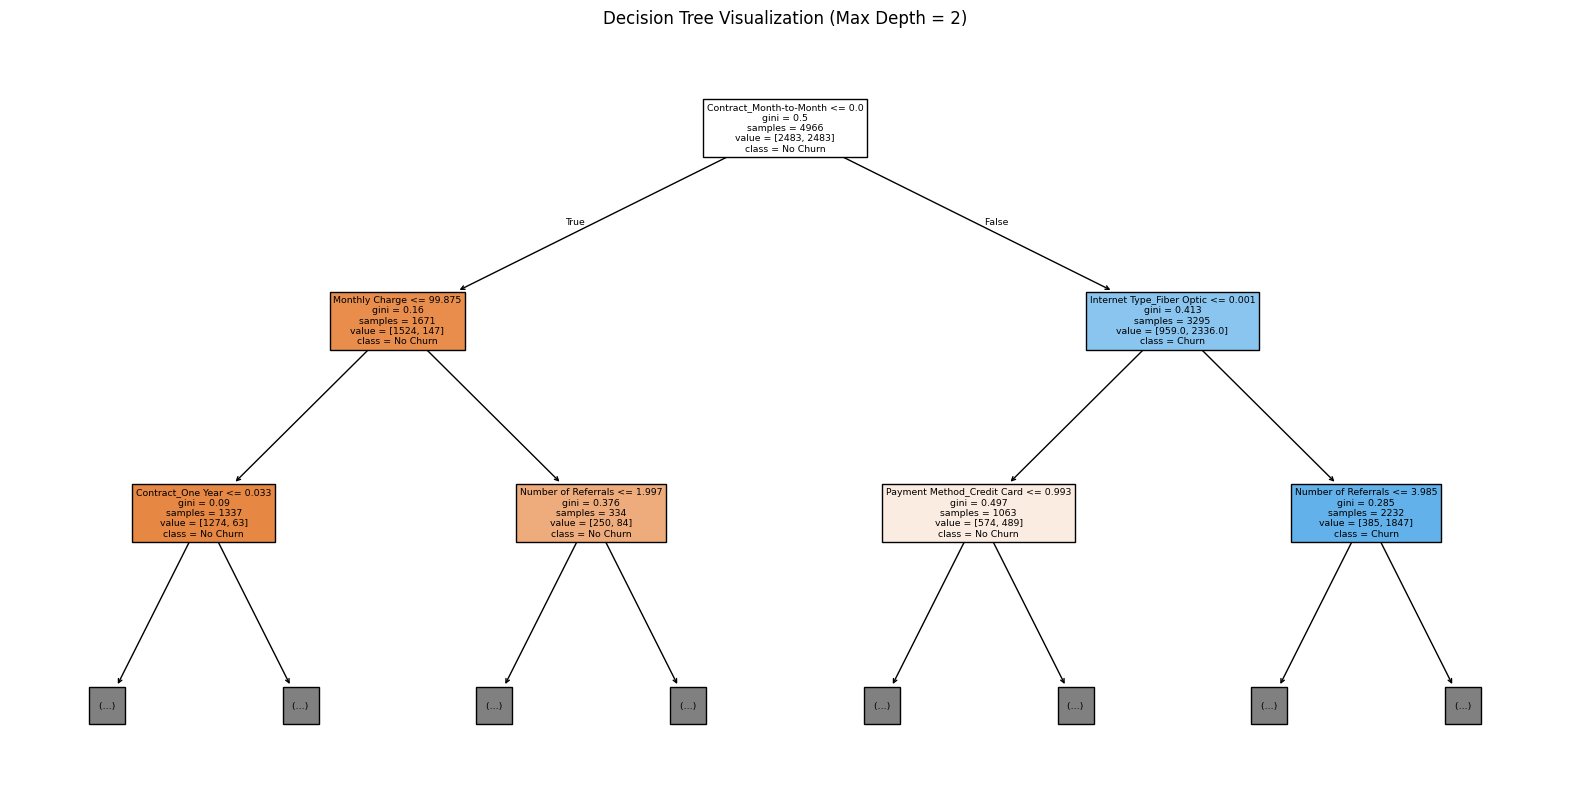

In [ ]:
ohe_feature_names = preprocess_tree.named_transformers_['cat'].get_feature_names_out(txt_cols)
all_feature_names = np.concatenate([ohe_feature_names, num_cols])

plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=all_feature_names, class_names=['No Churn', 'Churn'], filled=True, max_depth=2)
plt.title('Decision Tree Visualization (Max Depth = 2)')
plt.show()

### **Evaluation Metrics**

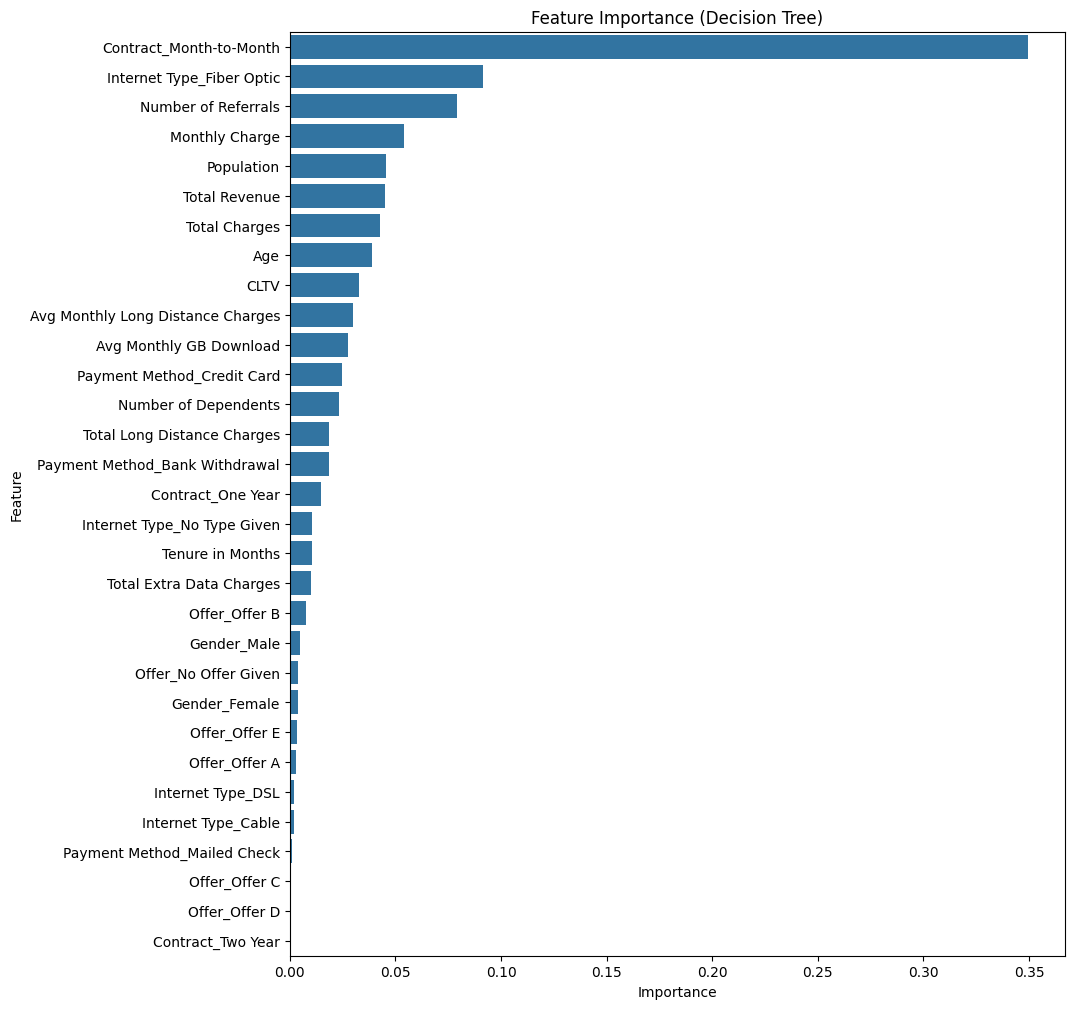

In [ ]:
importances = dt.feature_importances_

feature_importance_dfDT = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

feature_importance_dfDT = feature_importance_dfDT.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x='Importance', y='Feature', data=feature_importance_dfDT)
plt.title('Feature Importance (Decision Tree)')
plt.show()

In [ ]:
print("="*5, "Confusion Matrix", "="*5)
print(confusion_matrix(y_test, y_pred))

classreportDT = classification_report(y_test, y_pred)
print("\n")
print("="*15, "Classification Report:", "="*15)
print(classification_report(y_test, y_pred))

===== Confusion Matrix =====
[[523  98]
 [ 72 152]]


=============== Classification Report: ===============
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       621
           1       0.61      0.68      0.64       224

    accuracy                           0.80       845
   macro avg       0.74      0.76      0.75       845
weighted avg       0.81      0.80      0.80       845



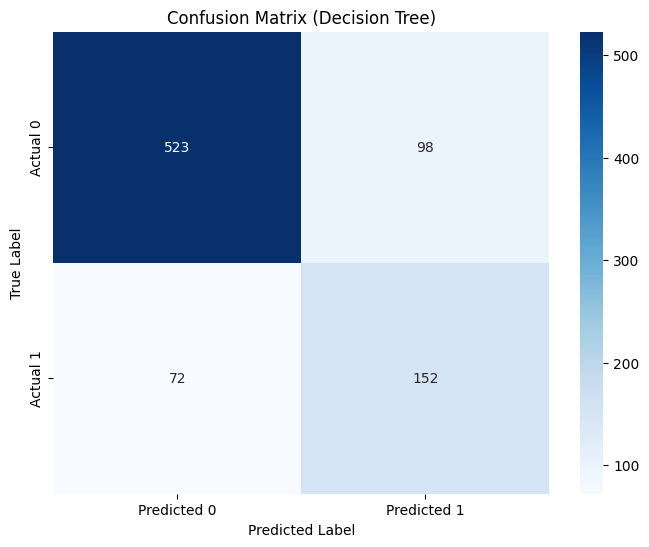

In [ ]:
cmDT = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cmDT, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Decision Tree)')
plt.show()

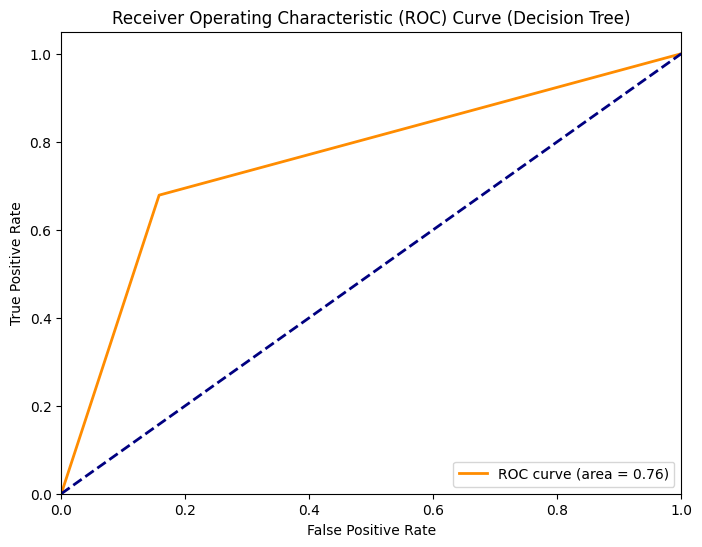

In [ ]:
y_pred_proba = dt.predict_proba(XDT_testproc)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Decision Tree)')
plt.legend(loc="lower right")
plt.show()

## **Naive Bayes**

In [ ]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_trainproc, y_train)

print("="*10, "SHAPE INFO", "="*10)
print("X_train:", X_train.shape)
print("X_train SMOTE :", X_train_sm.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_train SMOTE:", y_train_sm.shape)
print("y_test :", y_test.shape)

print("\n")
print("="*10, "TARGET DISTRIBUTION", "="*10)
print("Original Train:\n", y_train.value_counts(normalize=True))
print("\nOriginal Test:\n", y_test.value_counts(normalize=True))

print("\n")
print("="*10, "TARGET DISTRIBUTION (After SMOTE)", "="*10)
print("SMOTE Train:\n", y_train_sm.value_counts(normalize=True))

========== SHAPE INFO ==========
X_train: (3380, 36)
X_train SMOTE : (4966, 26)
X_test : (845, 36)
y_train: (3380,)
y_train SMOTE: (4966,)
y_test : (845,)


========== TARGET DISTRIBUTION ==========
Original Train:
 Churn
0    0.734615
1    0.265385
Name: proportion, dtype: float64

Original Test:
 Churn
0    0.734911
1    0.265089
Name: proportion, dtype: float64


========== TARGET DISTRIBUTION (After SMOTE) ==========
SMOTE Train:
 Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_train_sm, y_train_sm)

y_pred = naive_bayes.predict(X_testproc)

print("="*10, "Balanced Accuracy (SMOTE)", "="*10, "\n", balanced_accuracy_score(y_test, y_pred))

naive_bayes2 = GaussianNB()
naive_bayes2.fit(X_trainproc, y_train)

y_pred2 = naive_bayes2.predict(X_testproc)

print("="*10, "Balanced Accuracy", "="*10, "\n", balanced_accuracy_score(y_test, y_pred2))

========== Balanced Accuracy (SMOTE) ========== 
 0.7979928686450426
========== Balanced Accuracy ========== 
 0.8032623073383943


### Evaluation Metrics

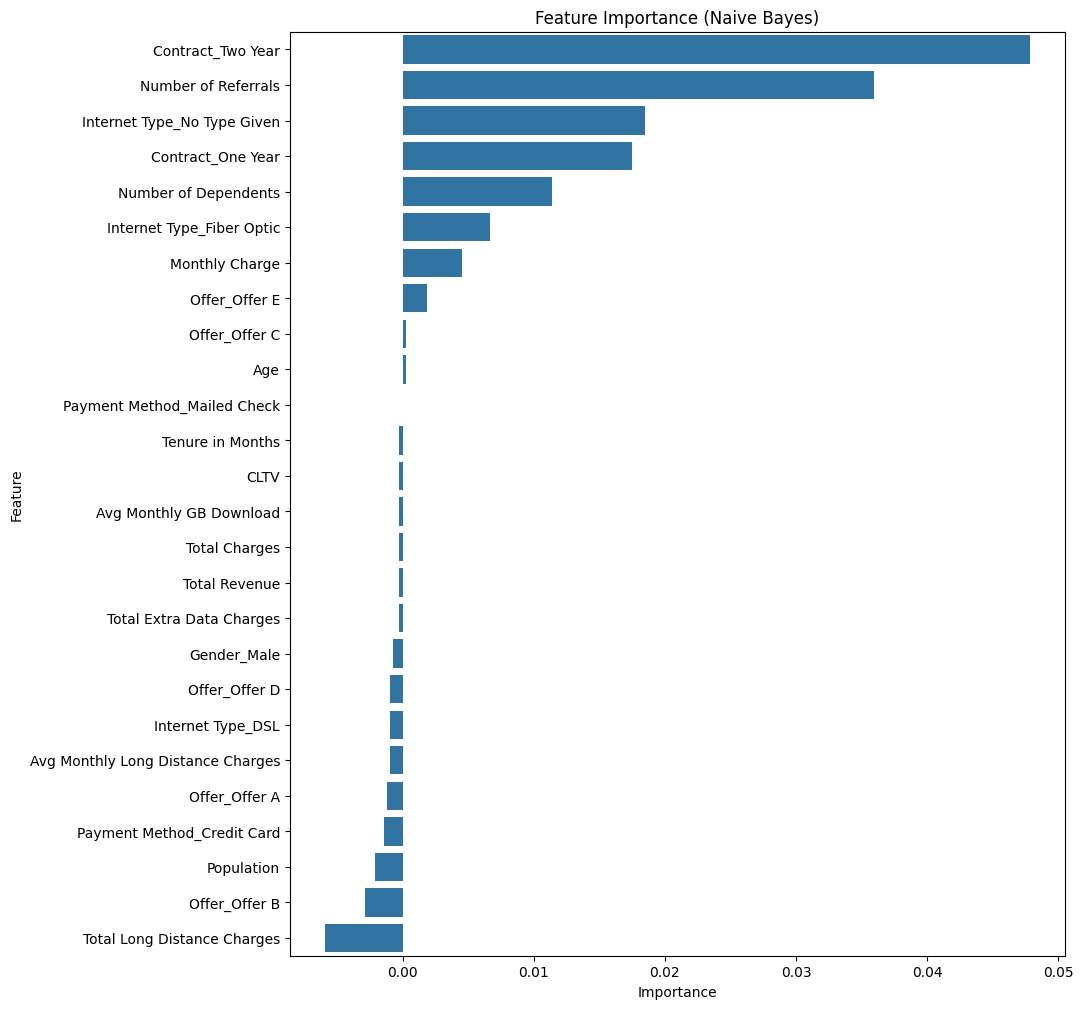

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(naive_bayes, X_testproc, y_test, random_state=42)
importancesNB = result.importances_mean

ohe_feature_names_nb = preprocess.named_transformers_['cat'].get_feature_names_out(txt_cols)
feature_names_for_nb = np.concatenate([ohe_feature_names_nb, num_cols])

feature_importance_dfNB = pd.DataFrame({
    'Feature': feature_names_for_nb,
    'Importance': importancesNB
})

feature_importance_dfNB = feature_importance_dfNB.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x='Importance', y='Feature', data=feature_importance_dfNB)
plt.title('Feature Importance (Naive Bayes)')
plt.show()

In [ ]:
print("="*10, "Confusion Matrix", "="*10)
print(confusion_matrix(y_test, y_pred))

classreportNB = classification_report(y_test, y_pred)
print("\n")
print("="*10, "Classification Report:", "="*10)
print(classification_report(y_test, y_pred))

========== Confusion Matrix ==========
[[481 140]
 [ 40 184]]


========== Classification Report: ==========
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       621
           1       0.57      0.82      0.67       224

    accuracy                           0.79       845
   macro avg       0.75      0.80      0.76       845
weighted avg       0.83      0.79      0.80       845



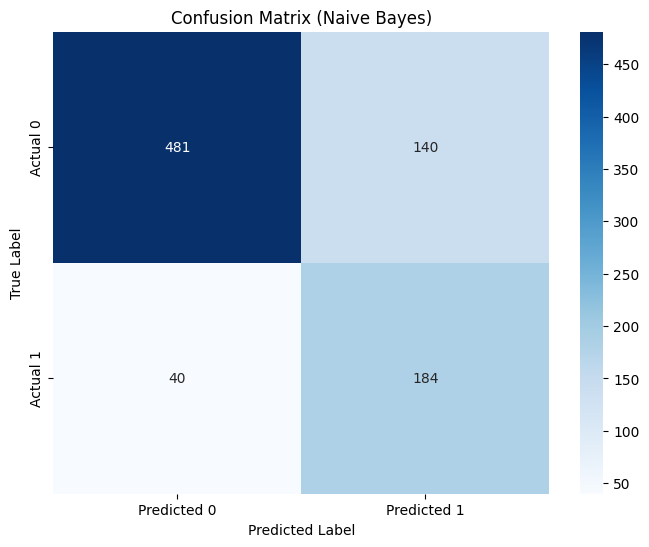

In [ ]:
cmNB = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cmNB, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Naive Bayes)')
plt.show()

## MLP Classifier

In [ ]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_trainproc, y_train)

print("="*10, "SHAPE INFO", "="*10)
print("X_train:", X_train.shape)
print("X_train SMOTE :", X_train_sm.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_train SMOTE:", y_train_sm.shape)
print("y_test :", y_test.shape)

print("\n")
print("="*10, "TARGET DISTRIBUTION", "="*10)
print("Original Train:\n", y_train.value_counts(normalize=True))
print("\nOriginal Test:\n", y_test.value_counts(normalize=True))

print("\n")
print("="*10, "TARGET DISTRIBUTION (After SMOTE)", "="*10)
print("SMOTE Train:\n", y_train_sm.value_counts(normalize=True))

========== SHAPE INFO ==========
X_train: (3380, 36)
X_train SMOTE : (4966, 26)
X_test : (845, 36)
y_train: (3380,)
y_train SMOTE: (4966,)
y_test : (845,)


========== TARGET DISTRIBUTION ==========
Original Train:
 Churn
0    0.734615
1    0.265385
Name: proportion, dtype: float64

Original Test:
 Churn
0    0.734911
1    0.265089
Name: proportion, dtype: float64


========== TARGET DISTRIBUTION (After SMOTE) ==========
SMOTE Train:
 Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
mlp = MLPClassifier(
  hidden_layer_sizes=(100, 50),
  activation='relu',
  solver='adam',
  alpha=0.0001,
  random_state=42,
  early_stopping=True,
  max_iter=1000
)
mlp.fit(X_train_sm, y_train_sm)

y_pred = mlp.predict(X_testproc)

print("="*10, "Balanced Accuracy (SMOTE)", "="*10, "\n", balanced_accuracy_score(y_test, y_pred))

mlp2 = MLPClassifier(
  hidden_layer_sizes=(100, 50),
  activation='relu',
  solver='adam',
  alpha=0.0001,
  random_state=42,
  early_stopping=True,
  max_iter=1000
)
mlp2.fit(X_trainproc, y_train)

y_pred2 = mlp2.predict(X_testproc)

print("="*10, "Balanced Accuracy", "="*10, "\n", balanced_accuracy_score(y_test, y_pred2))

========== Balanced Accuracy (SMOTE) ========== 
 0.7978490913273522
========== Balanced Accuracy ========== 
 0.7560674028065333


### Evaluation Metrics

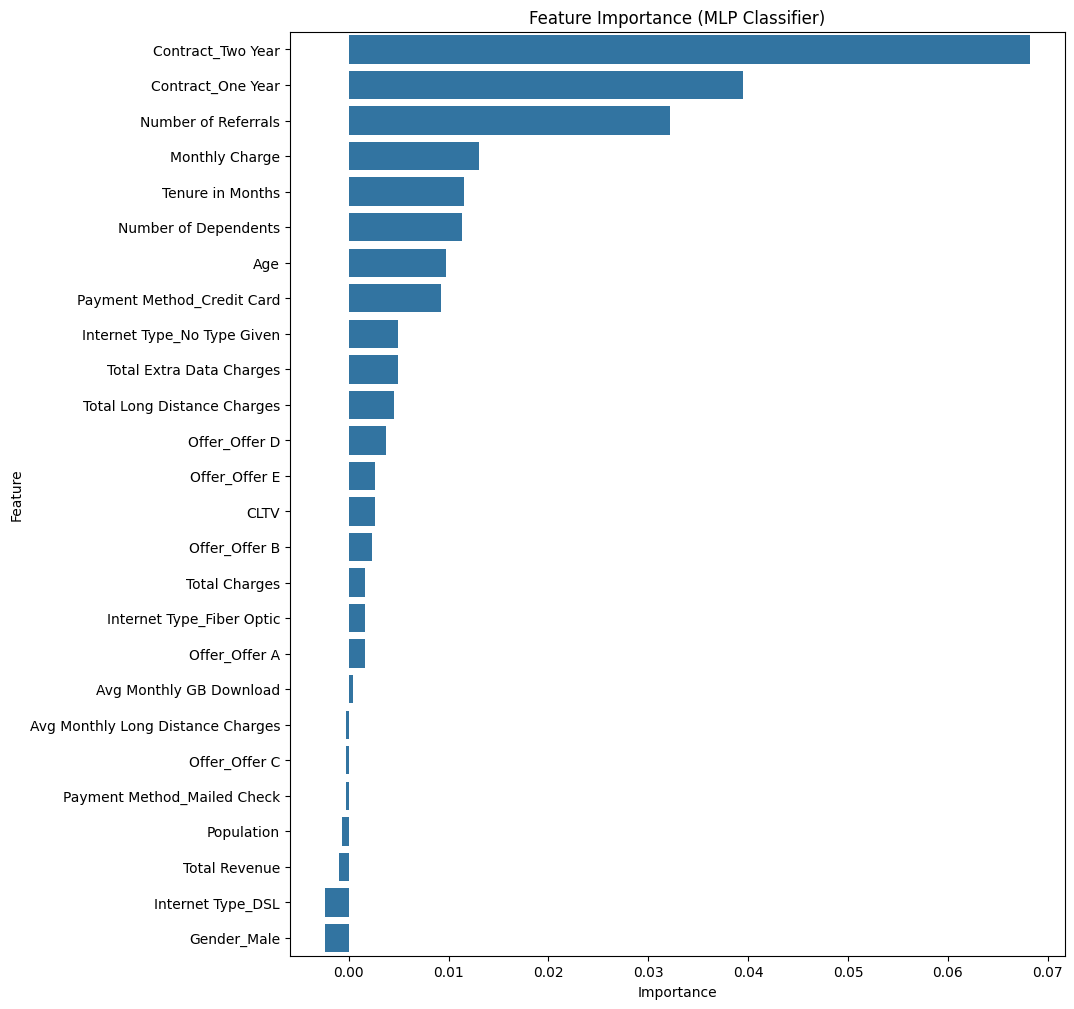

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(mlp, X_testproc, y_test, random_state=42)
importancesMLP = result.importances_mean

ohe_feature_names_mlp = preprocess.named_transformers_['cat'].get_feature_names_out(txt_cols)
feature_names_for_mlp = np.concatenate([ohe_feature_names_mlp, num_cols])

feature_importance_dfMLP = pd.DataFrame({
    'Feature': feature_names_for_mlp,
    'Importance': importancesMLP
})

feature_importance_dfMLP = feature_importance_dfMLP.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x='Importance', y='Feature', data=feature_importance_dfMLP)
plt.title('Feature Importance (MLP Classifier)')
plt.show()

In [ ]:
print("="*10, "Confusion Matrix", "="*10)
print(confusion_matrix(y_test, y_pred))

classreportMLP = classification_report(y_test, y_pred)
print("\n")
print("="*10, "Classification Report:", "="*10)
print(classreportMLP)

========== Confusion Matrix ==========
[[503 118]
 [ 48 176]]


========== Classification Report: ==========
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       621
           1       0.60      0.79      0.68       224

    accuracy                           0.80       845
   macro avg       0.76      0.80      0.77       845
weighted avg       0.83      0.80      0.81       845



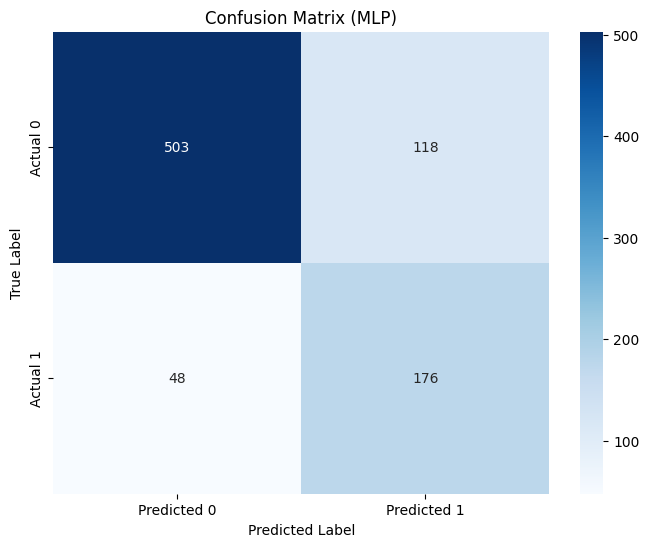

In [ ]:
cmMLP = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cmMLP, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (MLP)')
plt.show()

## Models Analysis

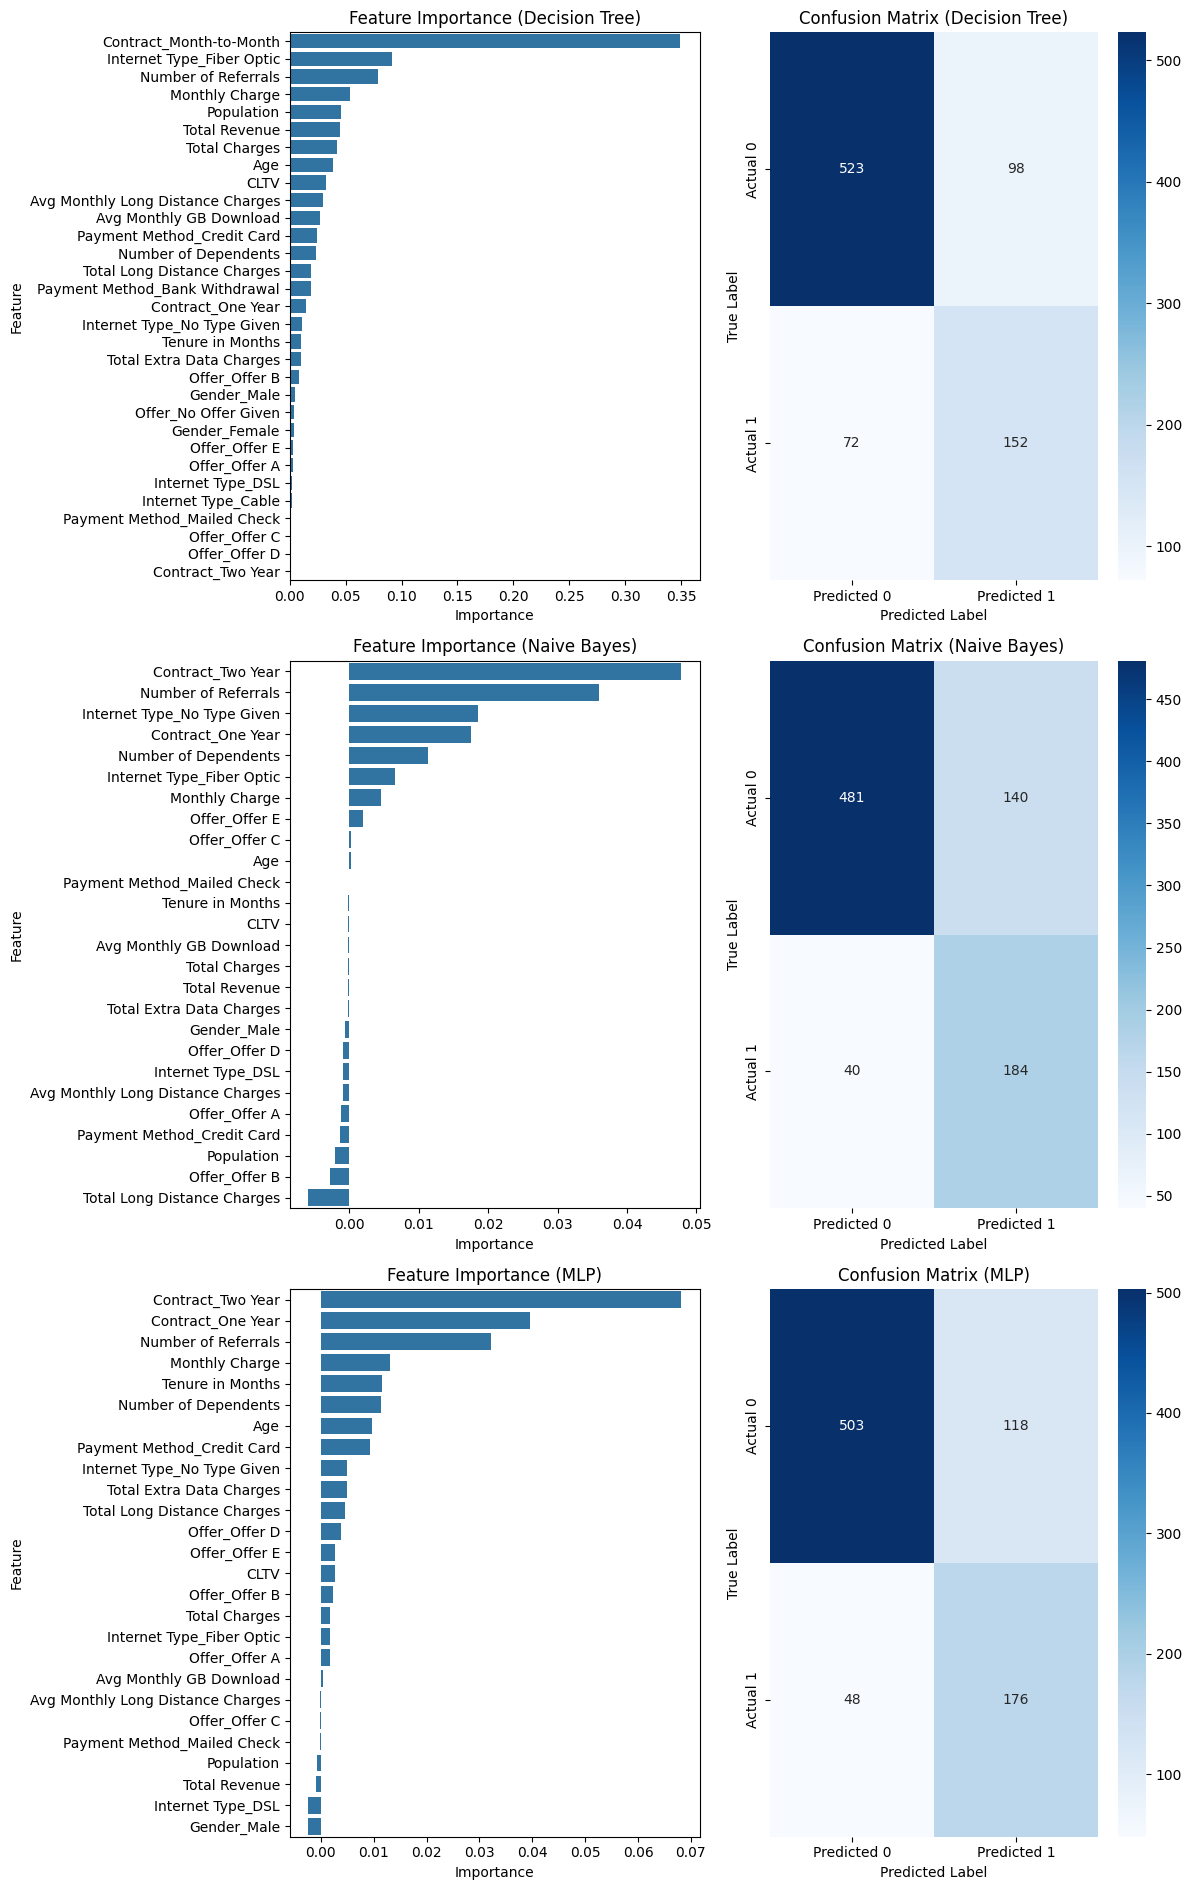

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 19))

# Decision Tree Feature Importance
sns.barplot(x='Importance', y='Feature', data=feature_importance_dfDT, ax=axes[0, 0])
axes[0, 0].set_title('Feature Importance (Decision Tree)')

# Decision Tree Confusion Matrix
sns.heatmap(cmDT, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            ax=axes[0, 1])
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_title('Confusion Matrix (Decision Tree)')

# Naive Bayes Feature Importance
sns.barplot(x='Importance', y='Feature', data=feature_importance_dfNB, ax=axes[1, 0])
axes[1, 0].set_title('Feature Importance (Naive Bayes)')

# Naive Bayes Confusion Matrix
sns.heatmap(cmNB, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            ax=axes[1, 1])
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_title('Confusion Matrix (Naive Bayes)')

# MLP Feature Importance
sns.barplot(x='Importance', y='Feature', data=feature_importance_dfMLP, ax=axes[2, 0])
axes[2, 0].set_title('Feature Importance (MLP)')

# MLP Confusion Matrix
sns.heatmap(cmMLP, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            ax=axes[2, 1])
axes[2, 1].set_xlabel('Predicted Label')
axes[2, 1].set_ylabel('True Label')
axes[2, 1].set_title('Confusion Matrix (MLP)')

plt.tight_layout()
plt.show()


In [ ]:
print("="*15, "Classification Report (Decision Tree)", "="*15)
print(classreportDT)
print("\n")

print("="*15, "Classification Report (Naive Bayes)", "="*15)
print(classreportNB)
print("\n")

print("="*15, "Classification Report (MLP)", "="*15)
print(classreportMLP)

=============== Classification Report (Decision Tree) ===============
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       621
           1       0.61      0.68      0.64       224

    accuracy                           0.80       845
   macro avg       0.74      0.76      0.75       845
weighted avg       0.81      0.80      0.80       845



=============== Classification Report (Naive Bayes) ===============
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       621
           1       0.57      0.82      0.67       224

    accuracy                           0.79       845
   macro avg       0.75      0.80      0.76       845
weighted avg       0.83      0.79      0.80       845



=============== Classification Report (MLP) ===============
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       621
           1       0.60      0.79  